In [1]:
pip install torch torchvision pycocotools

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import torch
import torchvision
import torch.optim as optim
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from PIL import Image

NUM_CLASSES = 2  
EPOCHS = 10
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_IMG_DIR = "../data/train/images"
TRAIN_ANN_FILE = "../data/annotations_train.json"
VAL_IMG_DIR = "../data/valid/images"
VAL_ANN_FILE = "../data/annotations_val.json"
SAVE_PATH = "../models/ssd/ssd_speedbump.pth"


class COCODatasetSSD(CocoDetection):
    def __getitem__(self, index):
        img, anns = super().__getitem__(index)

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            x1, y1, x2, y2 = x, y, x + w, y + h

            if w > 1 and h > 1:
                boxes.append([x1, y1, x2, y2])
                labels.append(1) 

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels}
        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

from torchvision.models.detection.ssd import SSDClassificationHead

def get_ssd_model(num_classes):
    model = torchvision.models.detection.ssd300_vgg16(weights="DEFAULT")

    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = [4, 6, 6, 6, 4, 4]  

    model.head.classification_head = SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    return model

def train():
    model = get_ssd_model(NUM_CLASSES).to(DEVICE)

    train_dataset = COCODatasetSSD(TRAIN_IMG_DIR, TRAIN_ANN_FILE)
    val_dataset = COCODatasetSSD(VAL_IMG_DIR, VAL_ANN_FILE)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Total Loss: {total_loss:.4f}")

    torch.save(model.state_dict(), SAVE_PATH)
    print(f"\n Model saved to {SAVE_PATH}")

if __name__ == "__main__":
    train()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Epoch 1/10: 100%|██████████| 873/873 [02:59<00:00,  4.87it/s]


Epoch 1 - Total Loss: 3667.3310


Epoch 2/10: 100%|██████████| 873/873 [02:09<00:00,  6.72it/s]


Epoch 2 - Total Loss: 2123.5660


...

Epoch 8 - Total Loss: 705.9763


Epoch 9/10: 100%|██████████| 873/873 [02:25<00:00,  6.00it/s]


Epoch 9 - Total Loss: 615.5363


Epoch 10/10: 100%|██████████| 873/873 [02:21<00:00,  6.18it/s]


Epoch 10 - Total Loss: 553.1271

✅ Model saved to ssd_speedbump.pth


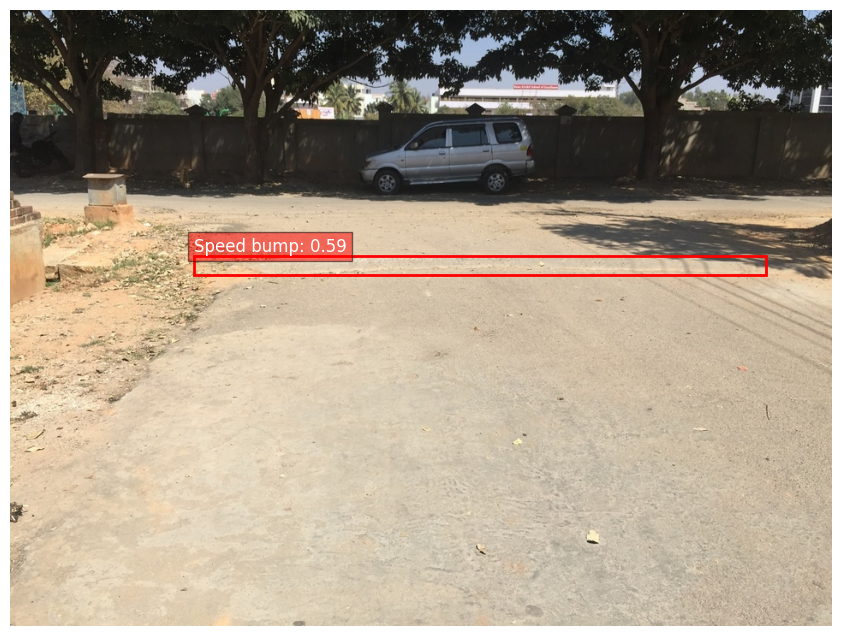

In [10]:
import os
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def load_model(model_path, num_classes=2):
    model = torchvision.models.detection.ssd300_vgg16(weights=None)
    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model

def predict_image(model, image_path, device='cuda', confidence_threshold=0.5):
    img = Image.open(image_path).convert("RGB")
    img_tensor = F.to_tensor(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        predictions = model(img_tensor)
    
    boxes = predictions[0]['boxes'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()
    
    keep = scores > confidence_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    
    return img, boxes, scores, labels

def visualize_prediction(image, boxes, scores, labels):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)
    
    for box, score, label in zip(boxes, scores, labels):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        
        label_text = f"Speed bump: {score:.2f}" if label == 1 else f"Background: {score:.2f}"
        ax.text(
            xmin, ymin - 5, label_text,
            color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5)
        )
    
    plt.axis('off')
    plt.show()

def run_prediction(image_path, model_path="../models/ssd/ssd_speedbump_tuned.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = load_model(model_path).to(device)
    
    image, boxes, scores, labels = predict_image(model, image_path, device)
    visualize_prediction(image, boxes, scores, labels)

if __name__ == "__main__":
    image_path = "15.jpg"  
    run_prediction(image_path)

In [ ]:
import torch
import torchvision
import json
import os
from PIL import Image
from tqdm import tqdm
from torchvision.transforms import functional as F
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

MODEL_PATH = "../models/ssd/ssd_speedbump.pth"
VAL_IMG_DIR = "../data/valid/images"
VAL_ANN_FILE = "../data/annotations_val.json"
NUM_CLASSES = 2
CONF_THRESH = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_JSON = "ssd_results.json"

def get_ssd_model(num_classes):
    model = torchvision.models.detection.ssd300_vgg16(weights="DEFAULT")
    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = [4, 6, 6, 6, 4, 4]
    model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    return model

def evaluate():
    model = get_ssd_model(NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    coco_gt = COCO(VAL_ANN_FILE)
    image_ids = coco_gt.getImgIds()
    images = coco_gt.loadImgs(image_ids)

    results = []

    for img_info in tqdm(images, desc="Evaluating SSD"):
        img_path = os.path.join(VAL_IMG_DIR, img_info["file_name"])
        image = Image.open(img_path).convert("RGB")
        image_tensor = F.to_tensor(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(image_tensor)[0]

        boxes = output["boxes"].cpu().numpy()
        scores = output["scores"].cpu().numpy()
        labels = output["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score < CONF_THRESH:
                continue
            x1, y1, x2, y2 = box
            results.append({
                "image_id": img_info["id"],
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score": float(score)
            })

    with open(OUTPUT_JSON, 'w') as f:
        json.dump(results, f)

    coco_dt = coco_gt.loadRes(OUTPUT_JSON)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    import numpy as np
    prec_vals = coco_eval.eval['precision'][0, :, 0, 0, 2]
    valid_prec = prec_vals[prec_vals >= 0]
    precision = float(np.mean(valid_prec)) if len(valid_prec) > 0 else 0.0
    recall = float(coco_eval.stats[8])
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

    print(f"
📊 Precision: {precision:.4f}")
    print(f"📊 Recall (AR@100): {recall:.4f}")
    print(f"📊 F1 Score: {f1:.4f}")

if __name__ == "__main__":
    evaluate()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Evaluating SSD: 100%|██████████| 1672/1672 [00:36<00:00, 46.12it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.30s).
Accumulating evaluation results...
DONE (t=0.18s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.558
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.841
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.630
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.597
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.616
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.616
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
import os
import torch
import torchvision
import torch.optim as optim
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.models.detection.ssd import SSDClassificationHead
from torch.utils.data import DataLoader
from tqdm import tqdm
import random
from PIL import Image, ImageEnhance

NUM_CLASSES = 2  
EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "../models/ssd/ssd_speedbump_tuned.pth"

TRAIN_IMG_DIR = "../data/train/images"
TRAIN_ANN_FILE = "../data/annotations_train.json"
VAL_IMG_DIR = "../data/valid/images"
VAL_ANN_FILE = "../data/annotations_val.json"

def random_augment(img):
    if random.random() > 0.5:
        img = F.hflip(img)
    if random.random() > 0.5:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    if random.random() > 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    return img

class COCODatasetSSD(CocoDetection):
    def __getitem__(self, index):
        img, anns = super().__getitem__(index)

        if self.transforms:
            img = self.transforms(img)

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w > 1 and h > 1:
                boxes.append([x, y, x + w, y + h])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels}
        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

def get_ssd_model(num_classes):
    model = torchvision.models.detection.ssd300_vgg16(weights="DEFAULT")
    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = [4, 6, 6, 6, 4, 4]
    model.head.classification_head = SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    return model

def train():
    model = get_ssd_model(NUM_CLASSES).to(DEVICE)

    train_dataset = COCODatasetSSD(TRAIN_IMG_DIR, TRAIN_ANN_FILE)
    val_dataset = COCODatasetSSD(VAL_IMG_DIR, VAL_ANN_FILE)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        print(f"Epoch {epoch+1} - Total Loss: {total_loss:.4f} - LR: {scheduler.get_last_lr()[0]:.6f}")

    torch.save(model.state_dict(), SAVE_PATH)
    print(f"\n Tuned SSD model saved to {SAVE_PATH}")

if __name__ == "__main__":
    train()


c:\Users\faizj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Epoch 1/20: 100%|██████████| 873/873 [02:29<00:00,  5.84it/s]


Epoch 1 - Total Loss: 4248.6851 - LR: 0.000500


Epoch 2/20: 100%|██████████| 873/873 [02:27<00:00,  5.94it/s]


...

Epoch 18 - Total Loss: 530.3893 - LR: 0.000005


Epoch 19/20: 100%|██████████| 873/873 [02:17<00:00,  6.36it/s]


Epoch 19 - Total Loss: 519.5603 - LR: 0.000005


Epoch 20/20: 100%|██████████| 873/873 [02:17<00:00,  6.34it/s]


Epoch 20 - Total Loss: 507.6969 - LR: 0.000005

✅ Tuned SSD model saved to ssd_speedbump_tuned.pth


In [ ]:
import os
import torch
import torchvision
import numpy as np
from torchvision.transforms import functional as F
from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
import json

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VAL_IMG_DIR = "../data/valid/images"
VAL_ANN_FILE = "../data/annotations_val.json"

class COCODatasetSSD(CocoDetection):
    def __getitem__(self, index):
        img, anns = super().__getitem__(index)
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w > 1 and h > 1:
                boxes.append([x, y, x + w, y + h])
                labels.append(1)
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {'boxes': boxes, 'labels': labels}
        img = F.to_tensor(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

def get_ssd_model(weight_path):
    model = torchvision.models.detection.ssd300_vgg16(weights=None, num_classes=2)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def evaluate_model(model, dataloader, coco_gt, json_out):
    model.eval()
    coco_results = []
    all_gt_binary = []
    all_pred_binary = []

    image_id = 0
    for images, targets in tqdm(dataloader, desc="Evaluating"):
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for i in range(len(images)):
            gt_boxes = targets[i]['boxes'].cpu().numpy()
            gt_labels = targets[i]['labels'].cpu().numpy()

            pred_boxes = outputs[i]['boxes'].detach().cpu().numpy()
            pred_scores = outputs[i]['scores'].detach().cpu().numpy()
            pred_labels = outputs[i]['labels'].detach().cpu().numpy()

            matched_gt = set()
            for pb, ps, pl in zip(pred_boxes, pred_scores, pred_labels):
                if ps < 0.5:
                    continue
                x1, y1, x2, y2 = pb
                width, height = x2 - x1, y2 - y1

                coco_results.append({
                    "image_id": coco_gt.getImgIds()[image_id],
                    "category_id": 1,
                    "bbox": [float(x1), float(y1), float(width), float(height)],
                    "score": float(ps)
                })

                matched = False
                for j, gt in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou = compute_iou(pb, gt)
                    if iou > 0.5:
                        matched = True
                        matched_gt.add(j)
                        break
                all_gt_binary.append(1)
                all_pred_binary.append(1 if matched else 0)

            for j in range(len(gt_boxes)):
                if j not in matched_gt:
                    all_gt_binary.append(1)
                    all_pred_binary.append(0)

            image_id += 1

    with open(json_out, "w") as f:
        json.dump(coco_results, f, indent=2)

    coco_dt = coco_gt.loadRes(json_out)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    stats = coco_eval.stats  

    precision = precision_score(all_gt_binary, all_pred_binary, zero_division=0)
    recall = recall_score(all_gt_binary, all_pred_binary, zero_division=0)
    f1 = f1_score(all_gt_binary, all_pred_binary, zero_division=0)

    return stats, precision, recall, f1

def main():
    dataset = COCODatasetSSD(VAL_IMG_DIR, VAL_ANN_FILE)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
    coco_gt = COCO(VAL_ANN_FILE)

    print("\n📊 Evaluating Baseline SSD:")
    model_base = get_ssd_model("../models/ssd/ssd_speedbump.pth")
    stats_base, p_base, r_base, f1_base = evaluate_model(model_base, dataloader, coco_gt, "baseline_ssd_results.json")

    print("\n📊 Evaluating Tuned SSD:")
    model_tuned = get_ssd_model("../models/ssd/ssd_speedbump_tuned.pth")
    stats_tuned, p_tuned, r_tuned, f1_tuned = evaluate_model(model_tuned, dataloader, coco_gt, "tuned_ssd_results.json")

    print("\n📈 Metric Comparison (mAP & AR):")
    names = ["AP@[IoU=0.50:0.95]", "AP@0.5", "AP@0.75", "AP_small", "AP_medium", "AP_large", 
             "AR@1", "AR@10", "AR@100", "AR_small", "AR_medium", "AR_large"]
    for i, name in enumerate(names):
        print(f"{name:25} | {stats_base[i]:10.4f} | {stats_tuned[i]:10.4f}")

    print("\n📈 Classification Metrics (IoU>0.5 match):")
    print(f"{'Precision':25} | {p_base:10.4f} | {p_tuned:10.4f}")
    print(f"{'Recall':25} | {r_base:10.4f} | {r_tuned:10.4f}")
    print(f"{'F1-score':25} | {f1_base:10.4f} | {f1_tuned:10.4f}")

if __name__ == "__main__":
    main()


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

📊 Evaluating Baseline SSD:


Evaluating: 100%|██████████| 418/418 [00:22<00:00, 18.78it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.50s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.558
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.841
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.630
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.597
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.616
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.616
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

c:\Users\faizj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\faizj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Evaluating: 100%|██████████| 418/418 [00:22<00:00, 18.78it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.26s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.515
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.743
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.589
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.272
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.541
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10